# Markov Switching Regime Segmentation
Here we implement a Hidden Markov Model (HMM) approach to market regime segmentation.
Specifically, we try to use a **Markov Switching Regression** model on the asset returns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

### Insert data-path here 
data_path = r'../../../data/master_data.csv'
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (6164, 27)


,Date,GSPC,VIX,SPY Volume,Gold,Oil,GDP,Core_Inflation,Unemployment,M2,...,MACD_Signal,MACD_Hist,GDP_YoY,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,2001-08-30,1129.030029,25.410000,17692600,275.399994,26.549999,14214.516,76.553,4.9,5243.8,...,-11.129843,-2.983369,0.004892,0.020421,0.088038,1520.77002,-0.257593,2.379999,3.180000,NaN
1,2001-08-31,1133.579956,24.920000,15985400,274.399994,27.200001,14214.516,76.553,4.9,5243.8,...,-12.009273,-3.517721,0.004892,0.020421,0.088038,1520.77002,-0.254601,-0.490000,5.210001,NaN
2,2001-09-04,1132.939941,25.850000,24473400,271.600006,26.930000,14214.516,76.118,5.0,5355.1,...,-12.909172,-3.599596,0.004892,0.012167,0.102962,1520.77002,-0.255022,0.930000,5.290001,NaN
3,2001-09-05,1131.739990,26.350000,21477100,272.000000,26.950001,14214.516,76.118,5.0,5355.1,...,-13.764448,-3.421104,0.004892,0.012167,0.102962,1520.77002,-0.255811,0.500000,4.350000,NaN
4,2001-09-06,1106.400024,28.610001,21653000,273.000000,27.580000,14214.516,76.118,5.0,5355.1,...,-14.919833,-4.621539,0.004892,0.012167,0.102962,1520.77002,-0.272474,2.260000,5.580000,NaN


Fit the model, k_regimes=2: Bull and Bear
- trend='c': Include a constant (mean) in each regime
- switching_variance=True: Allow volatility to be different in each regime

In [ ]:
df_clean = df.dropna(subset=[ret_col]).copy().reset_index(drop=True)
print("Fitting Markov Switching Model (2 regimes, switching variance)...")
endog = df_clean[ret_col]

mod = sm.tsa.MarkovRegression(endog, k_regimes=2, trend='c', switching_variance=True)
res = mod.fit(search_reps=20)
print(res.summary())

Fitting Markov Switching Model (2 regimes, switching variance)...
                        Markov Switching Model Results                        
Dep. Variable:                 Return   No. Observations:                 8066
Model:               MarkovRegression   Log Likelihood               25943.503
Date:                Sat, 21 Feb 2026   AIC                         -51875.005
Time:                        12:07:07   BIC                         -51833.033
Sample:                             0   HQIC                        -51860.645
                               - 8066                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0007      0.000     -1.791      0.073      -0.00

Map states to Bull/Bear Regimes

In [ ]:
# Fetch params from the results_gmm of the Markov Swichting regime
params = res.params

# Disentagle params
mean_0 = params['const[0]']
mean_1 = params['const[1]']
var_0 = params['sigma2[0]']
var_1 = params['sigma2[1]']

print(f"State 0: Mean = {mean_0:.6f}, Variance = {var_0:.6f}")
print(f"State 1: Mean = {mean_1:.6f}, Variance = {var_1:.6f}")

# We define the Bull state as the one with the higher mean return
if mean_0 > mean_1:
    bull_state = 0
    bear_state = 1
else:
    bull_state = 1
    bear_state = 0

print(f"\nAssigned State {bull_state} to Bull Regime")
print(f"Assigned State {bear_state} to Bear Regime")

# Get the smoothed probabilities of being in each state
smoothed_probs = res.smoothed_marginal_probabilities

# Assign regime based on the highest probability
df_clean['prob_bull'] = smoothed_probs[bull_state]
df_clean['prob_bear'] = smoothed_probs[bear_state]

# Label as 'bull' if prob_bull > 0.5, else 'bear'
df_clean['regime'] = np.where(df_clean['prob_bull'] > 0.5, 'bull', 'bear')

# Merge back to original dataframe
if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])
if 'regime' in df.columns:
    df = df.drop(columns=['regime'])

df = df.merge(df_clean[['Date', 'regime', 'prob_bull', 'prob_bear']], on='Date', how='left')

# Fill any initial NaNs (if any rows were dropped)
first_regime = df_clean['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nMarkov Switching regime mapping complete.")
print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))

State 0: Mean = -0.000685, Variance = 0.000343
State 1: Mean = 0.000872, Variance = 0.000048

Assigned State 1 to Bull Regime
Assigned State 0 to Bear Regime

Markov Switching regime mapping complete.

Regime Counts:
regime
bull    5655
bear    2411
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.701
bear    0.299
Name: proportion, dtype: float64


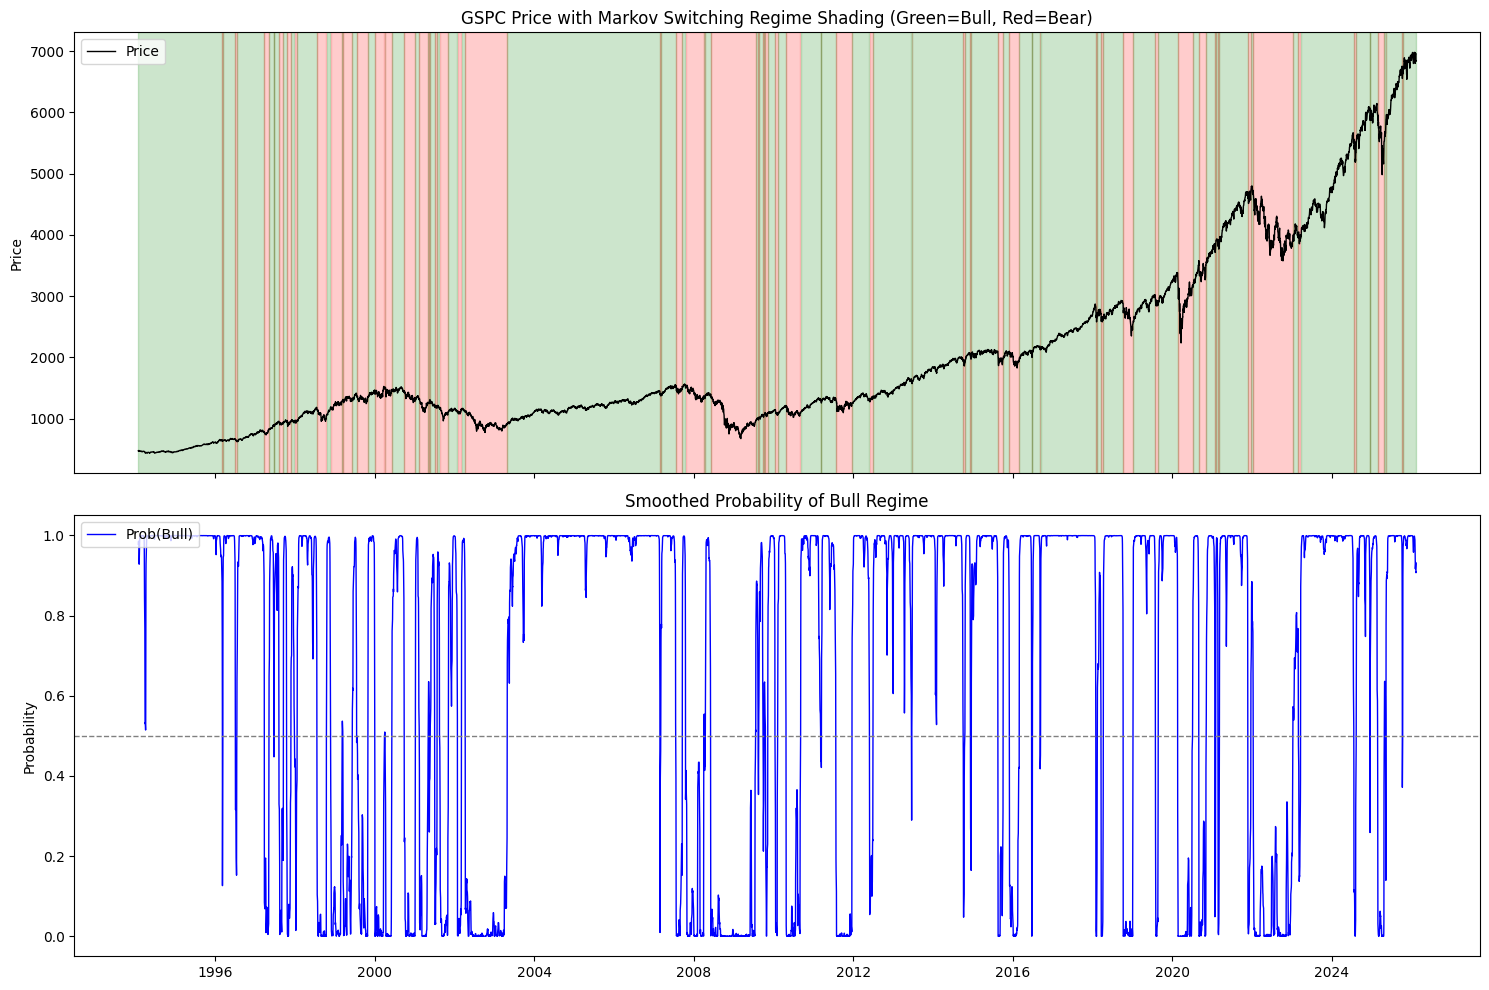

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Markov Switching Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Add shading
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

# Smoothed Probability of Bull Regime
ax2.plot(df['Date'], df['prob_bull'], color='blue', linewidth=1, label='Prob(Bull)')
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax2.set_title('Smoothed Probability of Bull Regime')
ax2.set_ylabel('Probability')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [ ]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

# write df to .csv
output_csv = r'../../../data/markov_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\markov_labeled_dataset.csv
